Top Recommendations for User 1:
movieId
1214    0.169503
1374    0.160106
1282    0.156410
1387    0.153925
1204    0.144815
Name: 0, dtype: float64
RMSE: 2.429747151193883
MAE: 2.065731623070824


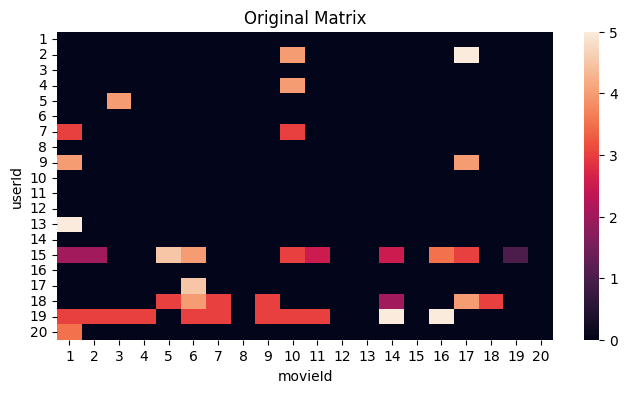

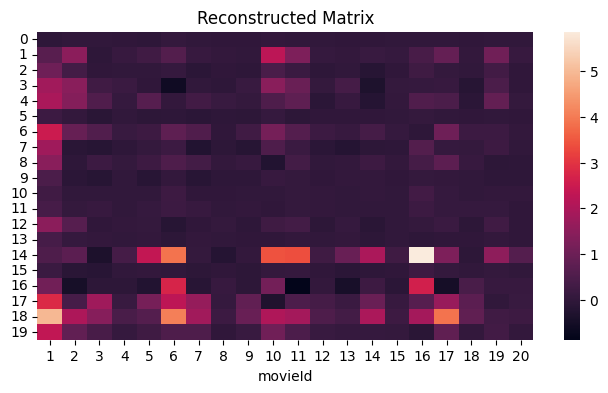

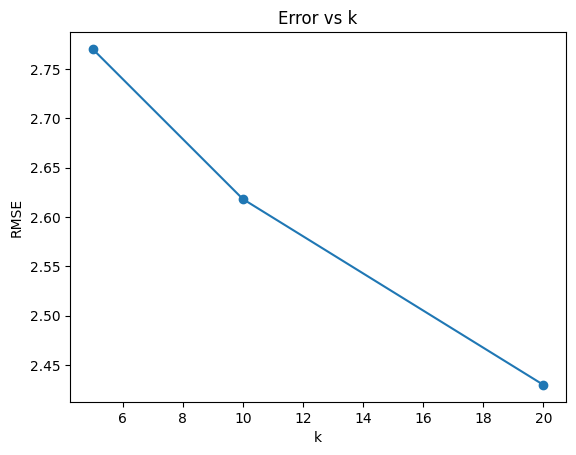

In [6]:
# SVD RECOMMENDATION SYSTEM

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse.linalg import svds

# 2. Load dataset
data = pd.read_csv('ratings.csv')

# 3. Preprocessing
user_item = data.pivot(index='userId', columns='movieId', values='rating')
mask = ~user_item.isna()

# 4. User-Item Matrix
matrix_filled = user_item.fillna(0)
R = matrix_filled.values

# 5. Normalize (mean centering)
user_mean = np.mean(R, axis=1)
R_demeaned = R - user_mean.reshape(-1, 1)

# 6–8. Apply SVD, reduce dimensions, reconstruct
k = 20
U, sigma, Vt = svds(R_demeaned, k=k)
sigma = np.diag(sigma)
R_pred = np.dot(np.dot(U, sigma), Vt) + user_mean.reshape(-1, 1)

# 9. Predict missing ratings
pred_df = pd.DataFrame(R_pred, columns=user_item.columns)

# 10. Top-N recommendations
def recommend_movies(user_id, n=5):
    user_ratings = pred_df.iloc[user_id - 1]
    watched = user_item.iloc[user_id - 1].dropna().index
    recs = user_ratings.drop(watched)
    return recs.sort_values(ascending=False).head(n)

print("Top Recommendations for User 1:")
print(recommend_movies(1))

# Evaluation
actual = R[mask]
predicted = R_pred[mask]

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("RMSE:", rmse)
print("MAE:", mae)

# Visualization

# Heatmap (original)
plt.figure(figsize=(8,4))
sns.heatmap(user_item.fillna(0).iloc[:20, :20])
plt.title("Original Matrix")
plt.show()

# Heatmap (reconstructed)
plt.figure(figsize=(8,4))
sns.heatmap(pred_df.iloc[:20, :20])
plt.title("Reconstructed Matrix")
plt.show()

# Error vs k
k_values = [5, 10, 20]
errors = []

for k in k_values:
    U, sigma, Vt = svds(R_demeaned, k=k)
    sigma = np.diag(sigma)
    R_temp = np.dot(np.dot(U, sigma), Vt) + user_mean.reshape(-1, 1)
    rmse = np.sqrt(mean_squared_error(R[mask], R_temp[mask]))
    errors.append(rmse)

plt.plot(k_values, errors, marker='o')
plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("Error vs k")
plt.show()

Top Recommendations for User 1:
movieId
1196    0.152903
1214    0.143250
1198    0.140674
1210    0.138499
1240    0.131160
Name: 0, dtype: float64
RMSE: 2.530372500038587
Precision@5: 0.0
Recall@5: 0.0


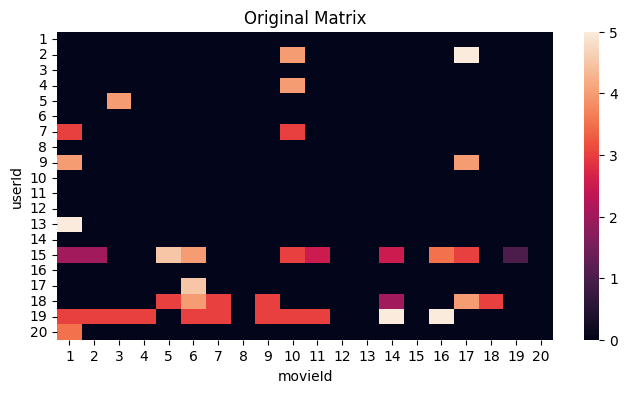

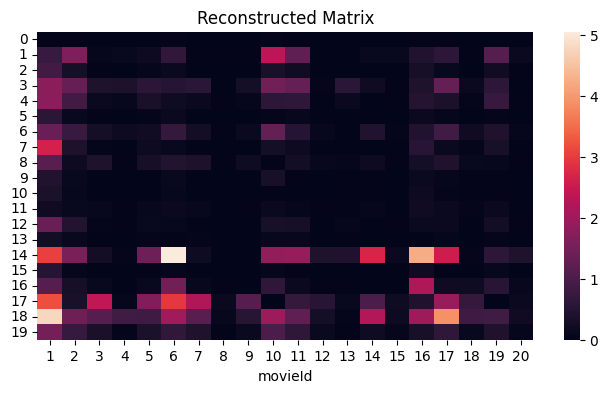

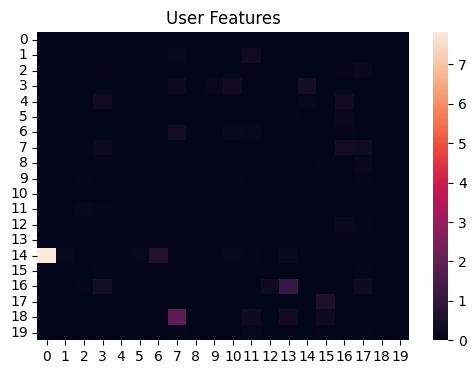

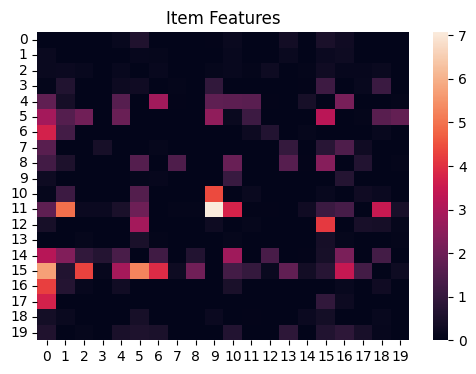

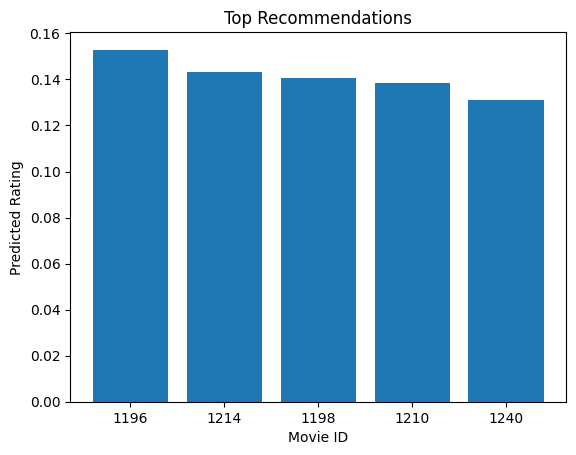

In [7]:
# NMF RECOMMENDATION SYSTEM

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

# 2. Load dataset
data = pd.read_csv('ratings.csv')

# 3. Create User-Item Matrix
user_item = data.pivot(index='userId', columns='movieId', values='rating')
mask = ~user_item.isna()

# 4. Handle missing values
matrix_filled = user_item.fillna(0)
R = matrix_filled.values

# 5–6. Apply NMF and factorize
k = 20
model = NMF(n_components=k, init='random', random_state=42)
W = model.fit_transform(R)   # User-feature
H = model.components_        # Item-feature

# 7. Reconstruct matrix
R_pred = np.dot(W, H)
pred_df = pd.DataFrame(R_pred, columns=user_item.columns)

# 8. Predict & Recommend
def recommend_movies(user_id, n=5):
    user_ratings = pred_df.iloc[user_id - 1]
    watched = user_item.iloc[user_id - 1].dropna().index
    recs = user_ratings.drop(watched)
    return recs.sort_values(ascending=False).head(n)

print("Top Recommendations for User 1:")
print(recommend_movies(1))

# Evaluation (RMSE)
actual = R[mask]
predicted = R_pred[mask]

rmse = np.sqrt(mean_squared_error(actual, predicted))
print("RMSE:", rmse)

# Precision@K and Recall@K
def precision_recall(user_id, k=5):
    actual_ratings = user_item.iloc[user_id - 1]
    predicted_ratings = pred_df.iloc[user_id - 1]

    relevant = actual_ratings[actual_ratings >= 3.5].index
    recommended = predicted_ratings.sort_values(ascending=False).head(k).index

    tp = len(set(recommended) & set(relevant))

    precision = tp / k
    recall = tp / len(relevant) if len(relevant) > 0 else 0

    return precision, recall

p, r = precision_recall(1)
print("Precision@5:", p)
print("Recall@5:", r)

# Visualization

# Reconstruction comparison
plt.figure(figsize=(8,4))
sns.heatmap(user_item.fillna(0).iloc[:20, :20])
plt.title("Original Matrix")
plt.show()

plt.figure(figsize=(8,4))
sns.heatmap(pred_df.iloc[:20, :20])
plt.title("Reconstructed Matrix")
plt.show()

# Latent features
plt.figure(figsize=(6,4))
sns.heatmap(W[:20, :])
plt.title("User Features")
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(H[:, :20])
plt.title("Item Features")
plt.show()

# Recommendation ranking chart
top_movies = recommend_movies(1)

plt.bar(top_movies.index.astype(str), top_movies.values)
plt.title("Top Recommendations")
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.show()